In [1]:
import numpy as np
import matplotlib
#matplotlib.use("Agg")  # remove/comment out if running interactively and want plt.show()
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.constants import c as light_speed

from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.Util import util, image_util
import lenstronomy.Util.simulation_util as sim_util

/Users/2014kz/Documents/PythonStuff/dspl/test/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


In [2]:
rng = np.random.default_rng(seed=42)
cosmo = FlatLambdaCDM(H0=70, Om0=0.27)

background_rms = .005  #  background noise per pixel
exp_time = 1000.  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 120  #  cutout pixel size per axis
deltaPix = 0.05  #  pixel size in arcsec (area per pixel = pixel_scale**2)
fwhm = 0.05  # full width at half maximum of PSF
psf_type = 'GAUSSIAN'

In [3]:
#define redshifts
zl = 0.222
zs1 = 0.609
zs2 = 2.025

In [25]:
#parameterisation functions 
ARCSEC_PER_RAD = 206264.80624709636
c = light_speed.to("km/s").value

def velocity_dispersion_to_theta_e(sig_v, zl, zs):
    d_s = cosmo.angular_diameter_distance(zs).value
    d_ls = cosmo.angular_diameter_distance_z1z2(zl, zs).value
    return 4 * np.pi * (sig_v/c)**2 * (d_ls/d_s) * ARCSEC_PER_RAD

def axis_ratio_to_e1e2(q, phi):
    e = (1.0 - q) / (1.0 + q)
    e1 = e * np.cos(2 * phi)
    e2 = e * np.sin(2 * phi)
    return e1, e2


def build_sie_kwargs(sig_v, q, phi, zl, zs, center_x=0.0, center_y=0.0):
    """Return an SIE kwargs dict for lenstronomy from CMU DeepLens params."""
    theta_E = velocity_dispersion_to_theta_e(sig_v, zl, zs)
    e1, e2 = axis_ratio_to_e1e2(q, phi)
    return {
        "theta_E": theta_E,
        "e1": e1,
        "e2": e2,
        "center_x": center_x,
        "center_y": center_y,
    }

def beta_scaling(zl, zs_from, zs_to):
    d_s_from = cosmo.angular_diameter_distance(zs_from).value
    d_ls_from = cosmo.angular_diameter_distance_z1z2(zl, zs_from).value
    d_s_to = cosmo.angular_diameter_distance(zs_to).value
    d_ls_to = cosmo.angular_diameter_distance_z1z2(zl, zs_to).value
    return (d_ls_to / d_s_to) / (d_ls_from / d_s_from)

def generate(rng):
    sig_v = rng.uniform(150, 300)
    q = rng.uniform(0.5, 1.0)
    phi = rng.uniform(0, 2*np.pi)
    return sig_v, q, phi

def find_beta(zl=zl, zs1=zs1, zs2=zs2):
    d_s1 = cosmo.angular_diameter_distance(zs1).value
    d_ls1 = cosmo.angular_diameter_distance_z1z2(zl, zs1).value

    d_s2 = cosmo.angular_diameter_distance(zs2).value
    d_ls2 = cosmo.angular_diameter_distance_z1z2(zl, zs2).value

    return (d_ls1 * d_s2) / (d_s1 * d_ls2)


In [28]:
sig_v_l, q_l, phi_l = generate(rng)
l_sie_kwargs_s1 = build_sie_kwargs(sig_v_l, q_l, phi_l, zl, zs1, 0.01, 0.0)

beta_l = beta_scaling(zl, zs1, zs2)
l_sie_kwargs_s2 = dict(l_sie_kwargs_s1)
l_sie_kwargs_s2["theta_E"] = l_sie_kwargs_s1["theta_E"] * beta_l


#leave sheer for now
#keep light profile fixed, can think about varying this as well
l_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.05, 'center_y': 0}]


sig_v_s1, q_s1, phi_s1 = generate(rng)
s1_sie_kwargs = build_sie_kwargs(sig_v_s1, q_s1, phi_s1, zs1, zs2, center_x=0.10, center_y=0.00)
s1_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0}]

s2_sersic_kwargs = [{'amp': 12, 'R_sersic': 0.08, 'n_sersic': 1, 'e1': 0.15, 'e2': -0.05, 'center_x': -0.10, 'center_y': 0.05}]


print(f"Main lens : sigma_v={sig_v_l:6.1f} km/s  q={q_l:.3f}  phi={phi_l:.3f} rad  "
      f"-> theta_E(zs=zs1)={l_sie_kwargs_s1['theta_E']:.4f}\"  "
      f"theta_E(zs=zs2)={l_sie_kwargs_s2['theta_E']:.4f}\"")
print(f"s1 lens   : sigma_v={sig_v_s1:6.1f} km/s  q={q_s1:.3f}  phi={phi_s1:.3f} rad  "
      f"-> theta_E={s1_sie_kwargs['theta_E']:.4f}\"")
beta = l_sie_kwargs_s2['theta_E'] / l_sie_kwargs_s1['theta_E']
print(f"beta = theta_E(zs2)/theta_E(zs1) = {beta:.4f}")
print(f"calculated beta = {find_beta(zl, zs1, zs2):.4f}")

Main lens : sigma_v= 246.6 km/s  q=0.911  phi=2.786 rad  -> theta_E(zs=zs1)=1.0512"  theta_E(zs=zs2)=1.4570"
s1 lens   : sigma_v= 184.1 km/s  q=0.777  phi=0.401 rad  -> theta_E=0.5647"
beta = theta_E(zs2)/theta_E(zs1) = 1.3860
calculated beta = 0.7215


In [29]:
#claude's double check function
def _direct_ratio_check(zl, zs_from, zs_to):
    """Independent re-derivation of beta_scaling(), purely as a cross-check."""
    d_s_from = cosmo.angular_diameter_distance(zs_from).value
    d_ls_from = cosmo.angular_diameter_distance_z1z2(zl, zs_from).value
    d_s_to = cosmo.angular_diameter_distance(zs_to).value
    d_ls_to = cosmo.angular_diameter_distance_z1z2(zl, zs_to).value
    return (d_ls_to * d_s_from) / (d_s_to * d_ls_from)


print(f"Main lens : sigma_v={sig_v_l:6.1f} km/s  q={q_l:.3f}  phi={phi_l:.3f} rad  "
      f"-> theta_E(zs=zs1)={l_sie_kwargs_s1['theta_E']:.4f}\"  "
      f"theta_E(zs=zs2)={l_sie_kwargs_s2['theta_E']:.4f}\"")
print(f"s1 lens   : sigma_v={sig_v_s1:6.1f} km/s  q={q_s1:.3f}  phi={phi_s1:.3f} rad  "
      f"-> theta_E={s1_sie_kwargs['theta_E']:.4f}\"")
print(f"beta used to rescale main-lens theta_E (zs1 -> zs2) = {beta_l:.4f}")
print(f"independent cross-check of that same beta           = {_direct_ratio_check(zl, zs1, zs2):.4f}")

Main lens : sigma_v= 246.6 km/s  q=0.911  phi=2.786 rad  -> theta_E(zs=zs1)=1.0512"  theta_E(zs=zs2)=1.4570"
s1 lens   : sigma_v= 184.1 km/s  q=0.777  phi=0.401 rad  -> theta_E=0.5647"
beta used to rescale main-lens theta_E (zs1 -> zs2) = 1.3860
independent cross-check of that same beta           = 1.3860


In [30]:
#defuncted section
'''
#define galaxy kwargs

#lens mass
l_sie_kwargs = {'theta_E': .66, 'center_x': 0.05, 'center_y': 0, 'e1': .07, 'e2': -0.03}
l_shear_kwargs = {'gamma1': 0.0, 'gamma2': -0.05}
#lens light
l_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.05, 'center_y': 0}]


#s1 mass
s1_sie_kwargs = {'theta_E': 0.03, 'center_x': 0.10, 'center_y': 0.00, 'e1': -0.10, 'e2': 0.10}
#s1_shear_kwargs = ...
#s1 light
s1_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0}]


#s2 light
s2_sersic_kwargs = [{'amp': 12, 'R_sersic': 0.08, 'n_sersic': 1, 'e1': 0.15, 'e2': -0.05, 'center_x': -0.10, 'center_y': 0.05}]
'''

"\n#define galaxy kwargs\n\n#lens mass\nl_sie_kwargs = {'theta_E': .66, 'center_x': 0.05, 'center_y': 0, 'e1': .07, 'e2': -0.03}\nl_shear_kwargs = {'gamma1': 0.0, 'gamma2': -0.05}\n#lens light\nl_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.05, 'center_y': 0}]\n\n\n#s1 mass\ns1_sie_kwargs = {'theta_E': 0.03, 'center_x': 0.10, 'center_y': 0.00, 'e1': -0.10, 'e2': 0.10}\n#s1_shear_kwargs = ...\n#s1 light\ns1_sersic_kwargs = [{'amp': 16, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0}]\n\n\n#s2 light\ns2_sersic_kwargs = [{'amp': 12, 'R_sersic': 0.08, 'n_sersic': 1, 'e1': 0.15, 'e2': -0.05, 'center_x': -0.10, 'center_y': 0.05}]\n"

In [31]:
#light model class
l_light_model = LightModel(
    light_model_list=['SERSIC_ELLIPSE']
)

s1_light_model  = LightModel(
    light_model_list=['SERSIC_ELLIPSE']
)

s2_light_model = LightModel(
    light_model_list=['SERSIC_ELLIPSE']
)

In [32]:
#lens model 

#this is to model s1 light getting lensed by the lens
s1_lens_model = LensModel(
    lens_model_list=['SIE'],
    lens_redshift_list=[zl],
    z_source=zs1,
    multi_plane=True,
    cosmo=cosmo
)

l_s1_kwargs = [l_sie_kwargs_s1]


#this is to model how s2 light getting lensed twice
s2_lens_model = LensModel(
    lens_model_list=['SIE', 'SIE'], #can add shear of s1
    lens_redshift_list=[zl, zs1],
    z_source=zs2,
    multi_plane=True,
    cosmo=cosmo
)

l_s1_s2_kwargs = [l_sie_kwargs_s2, s1_sie_kwargs]

In [33]:
kwargs_data = sim_util.data_configure_simple(
    numPix,
    deltaPix,
    exposure_time=exp_time,
    background_rms=background_rms,
)
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': deltaPix, 'truncation': 3}
kwargs_numerics = {"supersampling_factor": 2}

data_class = ImageData(**kwargs_data)
psf_class = PSF(**kwargs_psf)

In [34]:
#2 image models
#s1
s1_image_model = ImageModel(
    data_class=data_class,
    psf_class=psf_class,
    lens_model_class=s1_lens_model,
    lens_light_model_class=l_light_model,
    source_model_class=s1_light_model,
    kwargs_numerics=kwargs_numerics
)

#s2
s2_image_model = ImageModel(
    data_class=data_class,
    psf_class=psf_class,
    lens_model_class=s2_lens_model,
    lens_light_model_class=None,
    source_model_class=s2_light_model,
    kwargs_numerics=kwargs_numerics
)

In [35]:
s1_image = s1_image_model.image(
    kwargs_lens=l_s1_kwargs,
    kwargs_source=s1_sersic_kwargs,
    kwargs_lens_light=l_sersic_kwargs
)

s2_image = s2_image_model.image(
    kwargs_lens=l_s1_s2_kwargs,
    kwargs_source=s2_sersic_kwargs,
    kwargs_lens_light=None
)

image = s1_image + s2_image

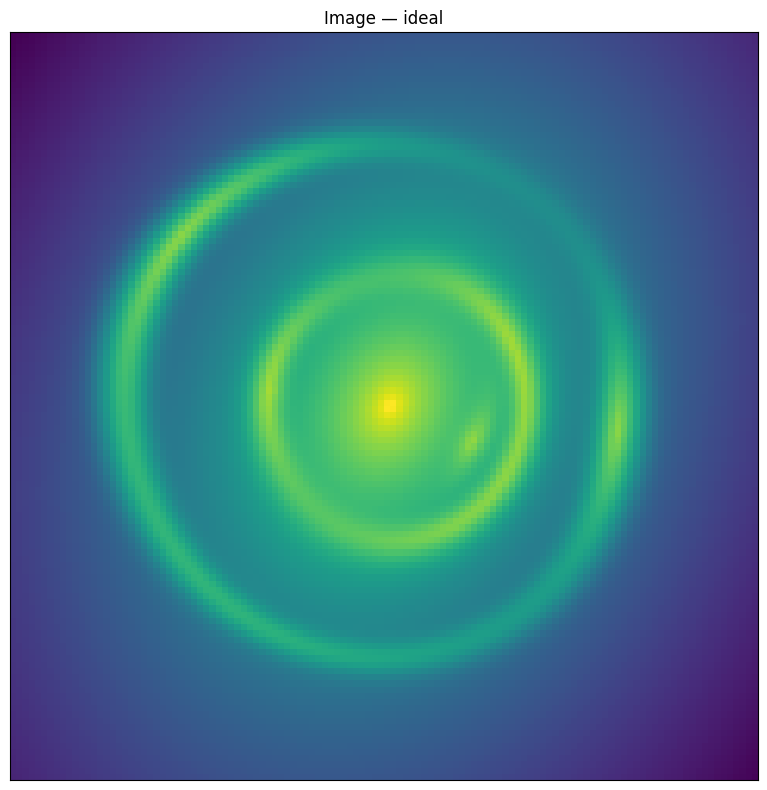

In [41]:
#test cell

x_grid, y_grid = util.make_grid(
    numPix=numPix,
    deltapix=deltaPix,
)

beta_x1, beta_y1 = s1_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_kwargs
)

beta_x2, beta_y2 = s2_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

alpha_x1, alpha_y1 = s1_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_kwargs
)

alpha_x2, alpha_y2 = s2_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

x_grid_2d = x_grid.reshape((numPix, numPix))
y_grid_2d = y_grid.reshape((numPix, numPix))

beta_x1_2d = beta_x1.reshape((numPix, numPix))
beta_y1_2d = beta_y1.reshape((numPix, numPix))

beta_x2_2d = beta_x2.reshape((numPix, numPix))
beta_y2_2d = beta_y2.reshape((numPix, numPix))

alpha_x1_2d = alpha_x1.reshape((numPix, numPix))
alpha_y1_2d = alpha_y1.reshape((numPix, numPix))

alpha_x2_2d = alpha_x2.reshape((numPix, numPix))
alpha_y2_2d = alpha_y2.reshape((numPix, numPix))


fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    np.log10(
        np.clip(image, 1e-6, None)
    ),
    origin="lower",
    cmap="viridis",
)

ax.set_title(
    "Image — ideal"
)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()

plt.show()

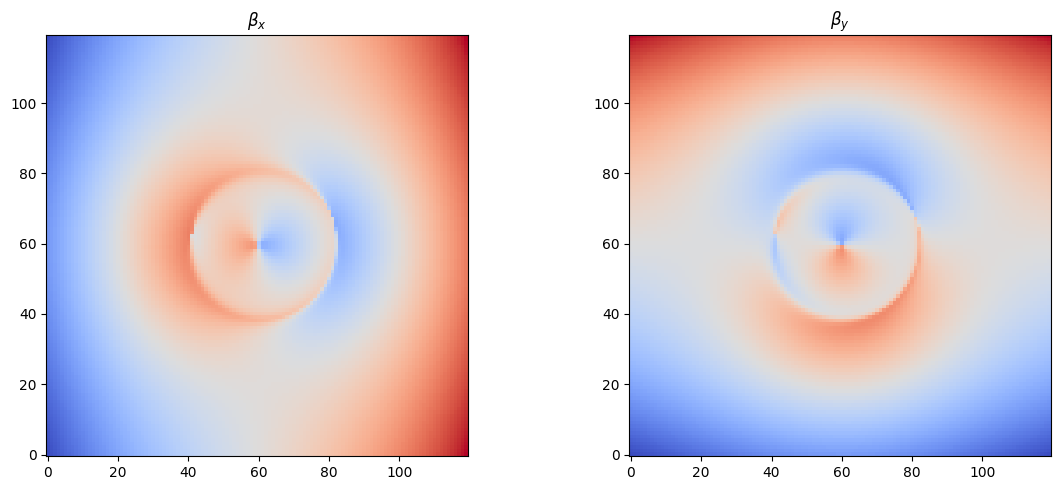

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(
    beta_x2_2d,
    origin="lower",
    cmap="coolwarm"
)
axes[0].set_title(r"$\beta_x$")

im2 = axes[1].imshow(
    beta_y2_2d,
    origin="lower",
    cmap="coolwarm"
)
axes[1].set_title(r"$\beta_y$")

plt.tight_layout()
plt.show()

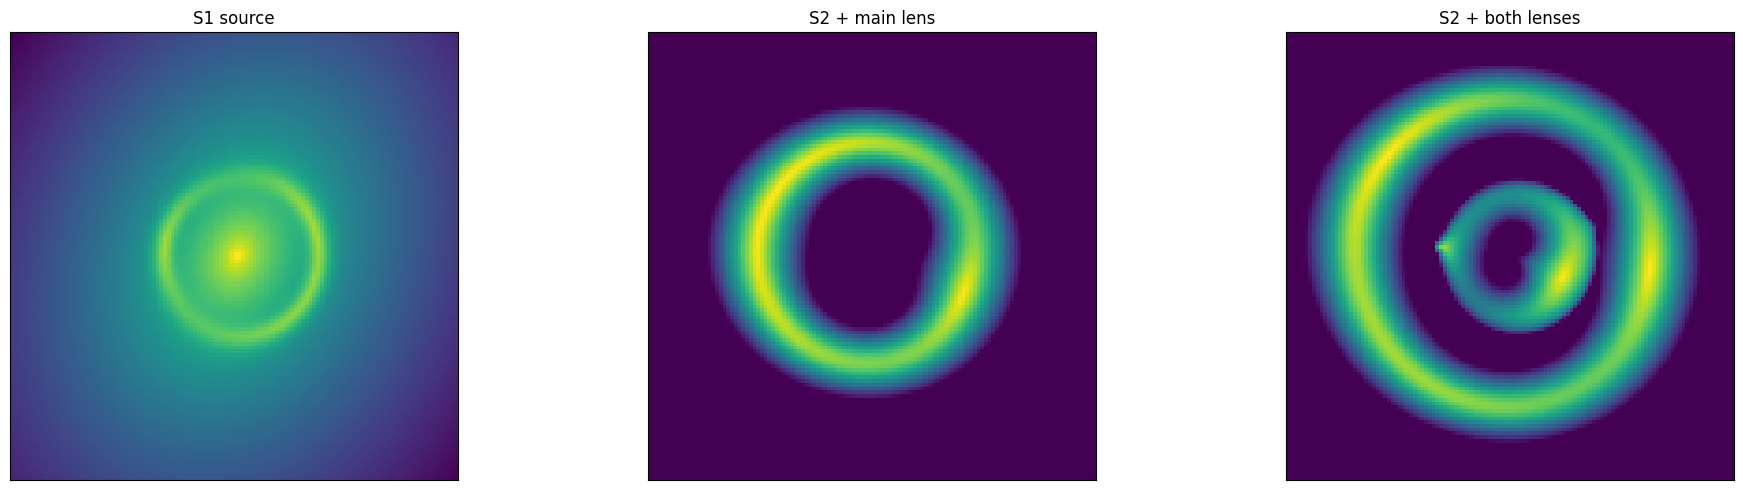

In [38]:
# S2 lensed only by the main foreground lens
s2_main_lens_model = LensModel(
    lens_model_list=['SIE'],
    lens_redshift_list=[zl],
    z_source=zs2,
    multi_plane=True,
    cosmo=cosmo
)

s2_main_image_model = ImageModel(
    data_class=data_class,
    psf_class=psf_class,
    lens_model_class=s2_main_lens_model,
    lens_light_model_class=None,
    source_model_class=s2_light_model,
    kwargs_numerics=kwargs_numerics
)

s2_main_only = s2_main_image_model.image(
    kwargs_lens=[l_sie_kwargs_s2],
    kwargs_source=s2_sersic_kwargs,
    kwargs_lens_light=None
)


fig, axes = plt.subplots(1, 3, figsize=(20, 5))

imgs = [
    s1_image,
    s2_main_only,
    s2_image
]

titles = [
    "S1 source",
    "S2 + main lens",
    "S2 + both lenses"
]

for ax, img, title in zip(axes, imgs, titles):
    ax.imshow(
        np.log10(np.clip(img, 1e-6, None)),
        origin="lower",
        cmap="viridis"
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


In [ ]:
poisson_noise = image_util.add_poisson(
    image,
    exp_time=exp_time,
)

background_noise = image_util.add_background(
    image,
    sigma_bkd=background_rms,
)

image_noisy = (image + poisson_noise + background_noise)

In [ ]:
x_grid, y_grid = util.make_grid(
    numPix=numPix,
    deltapix=deltaPix,
)

beta_x1, beta_y1 = s1_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_kwargs
)

beta_x2, beta_y2 = s2_lens_model.ray_shooting(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

alpha_x1, alpha_y1 = s1_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_kwargs
)

alpha_x2, alpha_y2 = s2_lens_model.alpha(
    x_grid,
    y_grid,
    l_s1_s2_kwargs
)

In [ ]:
x_grid_2d = x_grid.reshape((numPix, numPix))
y_grid_2d = y_grid.reshape((numPix, numPix))

beta_x1_2d = beta_x1.reshape((numPix, numPix))
beta_y1_2d = beta_y1.reshape((numPix, numPix))

beta_x2_2d = beta_x2.reshape((numPix, numPix))
beta_y2_2d = beta_y2.reshape((numPix, numPix))

alpha_x1_2d = alpha_x1.reshape((numPix, numPix))
alpha_y1_2d = alpha_y1.reshape((numPix, numPix))

alpha_x2_2d = alpha_x2.reshape((numPix, numPix))
alpha_y2_2d = alpha_y2.reshape((numPix, numPix))


In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

im = ax.imshow(
    np.log10(
        np.clip(image_noisy, 1e-6, None)
    ),
    origin="lower",
    cmap="viridis",
)

ax.set_title(
    "Combined DSPL Image — noisy"
)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
plt.tight_layout()

plt.show()


In [ ]:
'''
#setting up the lens galaxy
#mass profile
l_model_list = ['SIE', 'SHEAR', 'SIE']
l_kwargs_sie = {'theta_E': .66, 'center_x': 0.05, 'center_y': 0, 'e1': .07, 'e2': -0.03}
l_kwargs_shear = {'gamma1': 0.0, 'gamma2': -0.05}  # shear values to the source plane
s1_kwargs_sie = {'theta_E': 0.03, 'center_x': 0.10, 'center_y': 0.00, 'e1': -0.10, 'e2': 0.10}

kwargs_lens = [l_kwargs_sie, l_kwargs_shear, s1_kwargs_sie]

redshift_list = [zl, zl, zs1]

l_model_class = LensModel(
    l_model_list,
    lens_redshift_list=redshift_list,
    z_source=zs2,
    cosmo=cosmo,
    multi_plane=True
    )

#light profile source
source_list = ['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE']
s1_kwargs = {'amp': 16, 'R_sersic': 0.1, 'n_sersic': 1, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.1, 'center_y': 0}
s2_kwargs = {'amp': 12, 'R_sersic': 0.08, 'n_sersic': 1, 'e1': 0.15, 'e2': -0.05, 'center_x': -0.10, 'center_y': 0.05}

kwargs_source = [s1_kwargs, s2_kwargs]
source_model_class = LightModel(
    source_list,
    source_redshift_list=[zs1, zs2]
    )

#light profile lens
l_lens_list = ["SERSIC_ELLIPSE"]
l_kwargs_lens = {'amp': 16, 'R_sersic': 0.6, 'n_sersic': 2, 'e1': -0.1, 'e2': 0.1, 'center_x': 0.05, 'center_y': 0}
kwargs_lens_light = [l_kwargs_lens]
lens_light_model_class = LightModel(l_lens_list)
'''

In [ ]:
'''
_, _, ra_at_xy_0, dec_at_xy_0, _, _, Mpix2coord, _ = util.make_grid_with_coordtransform(numPix=numPix, deltapix=pixel_scale, center_ra=0, center_dec=0, subgrid_res=1, inverse=False)
kwargs_data = {'background_rms': background_rms,  # rms of background noise
               'exposure_time': exp_time,  # exposure time (or a map per pixel)
               'ra_at_xy_0': ra_at_xy_0,  # RA at (0,0) pixel
               'dec_at_xy_0': dec_at_xy_0,  # DEC at (0,0) pixel 
               'transform_pix2angle': Mpix2coord,  # matrix to translate shift in pixel in shift in relative RA/DEC (2x2 matrix). Make sure it's units are arcseconds or the angular units you want to model.
               'image_data': np.zeros((numPix, numPix))  # 2d data vector, here initialized with zeros as place holders that get's overwritten once a simulated image with noise is created.
              }

kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': pixel_scale, 'truncation': 3}
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}

data_class = ImageData(**kwargs_data)
psf_class = PSF(**kwargs_psf)

imageModel = ImageModel(data_class, psf_class, lens_model_class=l_model_class, 
                        source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
                        kwargs_numerics=kwargs_numerics)

image_model = imageModel.image(kwargs_lens, kwargs_source, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None)

poisson = image_util.add_poisson(image_model, exp_time=exp_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

data_class.update_data(image_real)
kwargs_data['image_data'] = image_real
'''

In [ ]:
'''
psf_class = PSF(**kwargs_psf)

imageModel = ImageModel(data_class, psf_class, lens_model_class=l_model_class, 
                        source_model_class=source_model_class, lens_light_model_class=lens_light_model_class,
                        kwargs_numerics=kwargs_numerics)

image_model = imageModel.image(kwargs_lens, kwargs_source, kwargs_lens_light=kwargs_lens_light, kwargs_ps=None)

poisson = image_util.add_poisson(image_model, exp_time=exp_time)
bkg = image_util.add_background(image_model, sigma_bkd=background_rms)
image_real = image_model + poisson + bkg

data_class.update_data(image_real)
kwargs_data['image_data'] = image_real
'''

In [ ]:
'''
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad(color='k', alpha=1.)
cmap.set_under('k')

v_min = -4
v_max = 1

f, axes = plt.subplots(1, 1, figsize=(6, 6), sharex=False, sharey=False)

ax = axes
im = ax.matshow(np.log10(image_real), origin='lower', vmin=v_min, vmax=v_max, cmap=cmap, extent=[0, 1, 0, 1])
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.autoscale(False)

plt.show()
'''

In [ ]:
x = np.arange(0, 10, 100)
y = x*23

plt.plot(x, y)
plt.show()